In [98]:
#const=0
import numpy as np
import matplotlib.pyplot as plt

def derivative_value(q, u, k, E):
    return (2*q**3 - 2*k**2*q-2*u*q + 2*k*E)/(E-2*k*q)
def get_all_roots(u, k, const, E):
    a = -1
    b = 0
    c = 2*k**2 + 2*u
    d = -4*k*E
    e = E**2 - u**2 + 2*k**2*u - k**4-const**2
    
    coefficients = [a, b, c, d, e]
    roots = np.roots(coefficients)
    
    roots_sorted = sorted(roots, key=lambda x: x.real)
    q1, q2, q3, q4 = roots_sorted
    
    all_real_roots = all(-1e-6 < abs(root.imag) < 1e-6 for root in roots_sorted)
    
    if all_real_roots:
        q_positive = []  
        q_negative = []  
        
        for root in roots_sorted:
            deriv_val = derivative_value(root.real, u, k, E)
            if deriv_val > 10**(-10):
                q_positive.append(root)
            elif deriv_val < -10**(-10):
                q_negative.append(root)
        q_positive_sorted = sorted(q_positive, key=lambda x: x.real)
        q_negative_sorted = sorted(q_negative, key=lambda x: x.real)

        if len(q_positive_sorted) == 2 and len(q_negative_sorted) == 2:
            q22, q44 = q_positive_sorted[0], q_positive_sorted[1]
            q11, q33 = q_negative_sorted[0], q_negative_sorted[1]
    else:
        if E<0:
            q11, q22, q44, q33 = roots_sorted
        if E>0:
            q11, q22, q33, q44 = roots_sorted
    return q11, q22, q33, q44

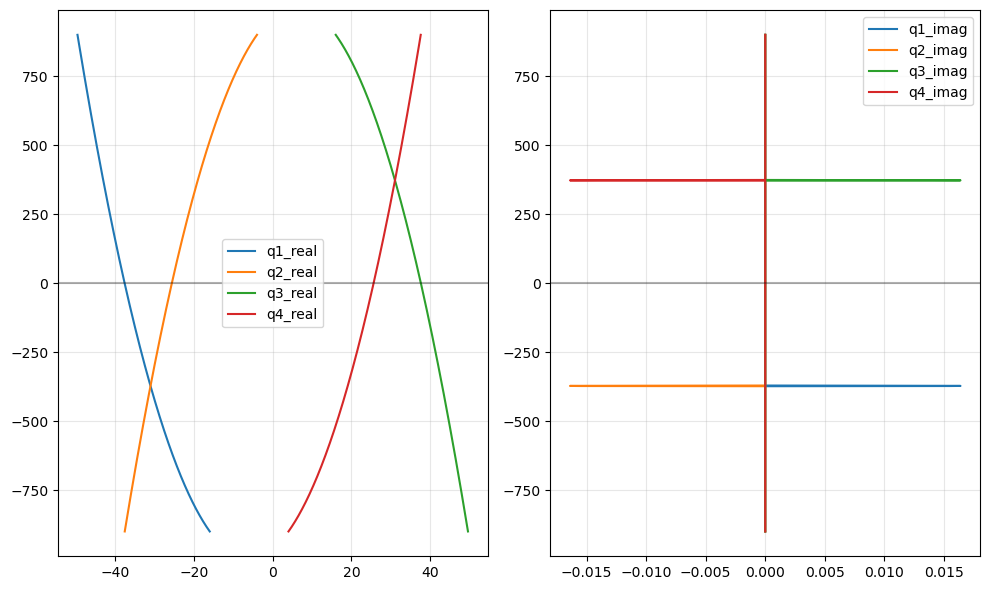

In [99]:
u = 1000
k = 6
const = u/1000
q1_real = []
q2_real = []
q3_real = []
q4_real = []
q1_imag = []
q2_imag = []
q3_imag = []
q4_imag = []
E_set = np.linspace(-900*const, 900*const, 10000)

for E in E_set:
    q111, q222, q333, q444 = get_all_roots(u, k, const, E)
    
    q1_real.append(q111.real)
    q2_real.append(q222.real)
    q3_real.append(q333.real)
    q4_real.append(q444.real)
    
    q1_imag.append(q111.imag)
    q2_imag.append(q222.imag)
    q3_imag.append(q333.imag)
    q4_imag.append(q444.imag)
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(q1_real, E_set, label='q1_real')
plt.plot(q2_real, E_set, label='q2_real')
plt.plot(q3_real, E_set, label='q3_real')
plt.plot(q4_real, E_set, label='q4_real')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
#plt.ylim(0,20)
#plt.ylim(-1,1)
#plt.ylim(-360,-380)
#plt.xlim(10.00,20.09)
#plt.xlim(-32,-30)
#plt.ylim(370,375)
#plt.axhline(y=373.61, color='green', linestyle='-', linewidth=1, alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(q1_imag, E_set, label='q1_imag')
plt.plot(q2_imag, E_set, label='q2_imag')
plt.plot(q3_imag, E_set, label='q3_imag')
plt.plot(q4_imag, E_set, label='q4_imag')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
#plt.ylim(370,375)
#plt.axhline(y=373.61, color='green', linestyle='-', linewidth=1, alpha=0.7)
#plt.ylim(-8,8)

plt.tight_layout()
plt.show()

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def derivative_value(q, u, k, E):
    return (-q**3 - 3*k*q**2 -3*k**2*q+u*q + k*u - k**3)*(-2)/E

def get_all_roots(u, k, const, E):
    a = -1
    b = -4*k
    c = -6*k**2 + 2*u
    d = -4*k**3+4*u*k
    e = E**2 - u**2 + 2*k**2*u - k**4-const**2

    coefficients = [a, b, c, d, e]
    roots = np.roots(coefficients)
    
    roots_sorted = sorted(roots, key=lambda x: x.real)
    q1, q2, q3, q4 = roots_sorted
    
    all_real_roots = all(-1e-6 < abs(root.imag) < 1e-6 for root in roots_sorted)
    
    if all_real_roots:
        q_positive = []  # 导数 >= 0 的根
        q_negative = []  # 导数 < 0 的根
        
        for root in roots_sorted:
            deriv_val = derivative_value(root.real, u, k, E)
            if deriv_val > 10**(-10):
                q_positive.append(root)
            elif deriv_val < -10**(-10):
                q_negative.append(root)

        q_positive_sorted = sorted(q_positive, key=lambda x: x.real)
        q_negative_sorted = sorted(q_negative, key=lambda x: x.real)
        
        if len(q_positive_sorted) == 2 and len(q_negative_sorted) == 2:
            q22, q44 = q_positive_sorted[0], q_positive_sorted[1]
            q11, q33 = q_negative_sorted[0], q_negative_sorted[1]

    else:
        if E<0 and k>0:
        
            q22, q11, q44, q33= roots_sorted
        if E>0 and k>0:
        
            q11, q22, q33, q44 = roots_sorted
        if E<0 and k<0:
       
            q22, q11, q44, q33 = roots_sorted
        if E>0 and k<0:
        
            q11, q22, q33, q44 = roots_sorted

    return q11, q22, q33, q44

In [103]:
def liumidu(diyiyinzi,dieryinzi,xquan,k):
    didiyi=2*(diyiyinzi.conjugate()*(xquan)*diyiyinzi-dieryinzi.conjugate()*(xquan)*dieryinzi).imag
    didier=2*k*(diyiyinzi.conjugate()*diyiyinzi-dieryinzi.conjugate()*dieryinzi)
    return didiyi-didier

In [ ]:
def calculate_probabilities_new_method(u, k, Z, E_set):
    const = u/1000
    H = 2*Z*(u)**0.5 
    a_set = []
    b_set = []
    c_set = []
    d_set = []
    z_set = []
    
    for E in E_set:
        qwei = get_all_roots(u, k, 0 , E)[3]
        bf1 = 1
        bf2 = 0

        k2 = get_all_roots(u, k, const, E)[1].real+1j*abs(get_all_roots(u, k, const, E)[1].imag)
        af1 = -const/(((k2+k)**2-u-E)**2+const**2)**0.5
        af2 = ((k2+k)**2-u-E)/(((k2+k)**2-u-E)**2+const**2)**0.5

        k4 =  get_all_roots(u, k, const, E)[3].real+1j*abs(get_all_roots(u, k, const, E)[3].imag)
        cf1 = -const/(((k4+k)**2-u-E)**2+const**2)**0.5
        cf2 = ((k4+k)**2-u-E)/(((k4+k)**2-u-E)**2+const**2)**0.5

        q2 = get_all_roots(u, k, 0, E)[1].real
        q4 = get_all_roots(u, k, 0, E)[3].real

        dd1 = (qwei + q2)*bf2 - ((k4 + q2 - H/(1j))*cf2*bf1*(qwei + q4))/((q4 + k4 - H/(1j))*cf1)
        dd2 = (k4 + q2 - H/(1j))*(-k2 -q4 + H/(1j))*cf2*af1/((q4 + k4 - H/(1j))*cf1) + (k2 +q2 - H/(1j))*af2
        
        d1 = dd1/dd2
        c1 = (d1*((-q4 - k2 + H/(1j))*af1) + (qwei + q4)*bf1)/((q4 + k4 - H/(1j))*cf1)
        b1 = c1*cf1 + d1*af1 - bf1
        a1 = c1*cf2 + d1*af2 - bf2

        d11 = ((abs(d1)**2 * (abs(af1)**2 - abs(af2)**2) * (1j)*(k2)).imag +k*abs(d1)**2 *(abs(af1)**2 - abs(af2)**2))/((1j*qwei*(abs(bf1)**2 - abs(bf2)**2)).imag+k*(abs(bf1)**2 - abs(bf2)**2))
        if -10**(-10)< k4.imag <10**(-10):
            c11 = ((abs(c1)**2 * (abs(cf1)**2 - abs(cf2)**2) * (1j)*(k4)).imag +k*abs(c1)**2 *(abs(cf1)**2 - abs(cf2)**2))/((1j*qwei*(abs(bf1)**2 - abs(bf2)**2)).imag+k*(abs(bf1)**2 - abs(bf2)**2))
        else:
            c11=0

        b11 = (abs(b1)**2  * (q4)  +k*abs(b1)**2) /((1j*qwei*(abs(bf1)**2 - abs(bf2)**2)).imag+k*(abs(bf1)**2 - abs(bf2)**2))
 
        a11 = (abs(a1)**2  * (-q2)  -k*abs(a1)**2)/((1j*qwei*(abs(bf1)**2 - abs(bf2)**2)).imag+k*(abs(bf1)**2 - abs(bf2)**2))
     

        a_set.append(a11)
        b_set.append(b11)
        c_set.append(c11)
        d_set.append(d11)
        z_set.append(a11 + b11 + c11 + d11)
    
    return a_set, b_set, c_set, d_set,z_set

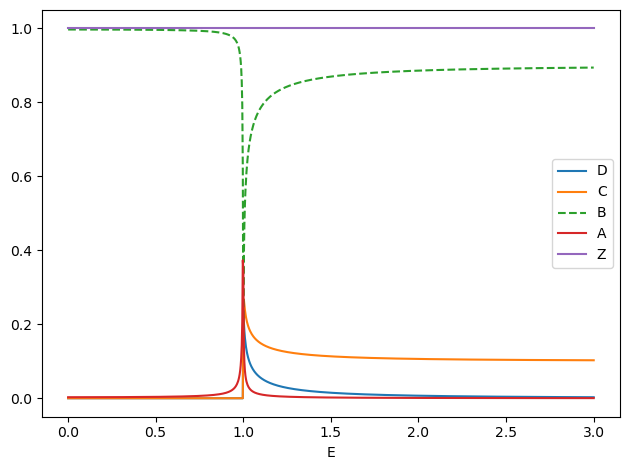

In [96]:
if __name__ == "__main__":
    u = 1000
    k = 10**(-6)
    Z = 3
    c_val = u/1000
    
    E_set1 = np.linspace(0.001*c_val, 3*c_val, 1000)
    a_set1, b_set1, c_set1, d_set1, z_set1 = calculate_probabilities_new_method(u, k, Z, E_set1)
    #plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    plt.plot(E_set1, z_set1, label='Z')
    plt.xlabel('E')
    plt.legend()
    plt.tight_layout()
    #plt.ylim(-0.1,1.1)
    plt.show()

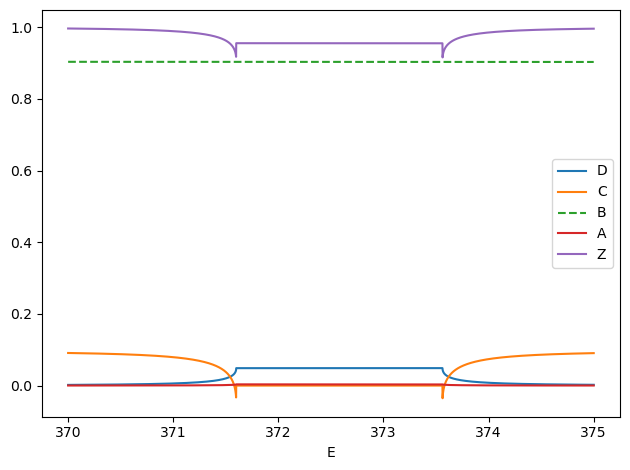

In [104]:
if __name__ == "__main__":
    u = 1000
    k = 6
    Z = 3
    c_val = u/1000
    
    E_set1 = np.linspace(370*c_val, 375*c_val, 4000)
    a_set1, b_set1, c_set1, d_set1, z_set1 = calculate_probabilities_new_method(u, k, Z, E_set1)
    #plt.figure(figsize=(5, 3))
    plt.plot(E_set1, d_set1, label='D')  
    plt.plot(E_set1, c_set1, label='C')
    plt.plot(E_set1, b_set1, label='B', linestyle='--')
    plt.plot(E_set1, a_set1, label='A')
    plt.plot(E_set1, z_set1, label='Z')
    plt.xlabel('E')
    plt.legend()
    plt.tight_layout()
    #plt.ylim(-0.1,1.1)
    plt.show()